In [17]:
import NNMFit
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import os

In [19]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/debug_bdt/plots_fit_result_2D"
os.makedirs(plotting_path, exist_ok=True)

In [14]:
font_axis_label = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 22}
font_title      = {'family': 'serif', 'color': 'black', 'weight': 'bold',   'size': 20}
font_legend     = font_manager.FontProperties(family='serif', weight='normal', style='normal', size=13)

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams.update({'font.family': 'serif'})

In [9]:
def plot_2d_scan(
    xs, ys, dllhs,
    best_fits=None,
    labels=None,
    colors=None,
    levels=None,
    levlabels=None,
    x_param="astro_norm",
    y_param="gamma_astro",
    x_label=r"$\Phi_0$",
    y_label=r"$\gamma$",
    heatmap=False,
    legend_title=None,
    ax=None,
    save_path=None,
):
    """Plot 2D likelihood scan contours with optional heatmap overlay.

    Parameters
    ----------
    xs, ys, dllhs : array or list of arrays
        Scan grid coordinates and -2*delta-log-likelihood values.
        Pass a single array for one scan, or a list for comparison.
    best_fits : dict or list of dicts, optional
        Best-fit parameter dicts (keys: x_param, y_param).  One per scan.
    labels : str or list of str, optional
        Legend label per scan.
    colors : str or list of str, optional
        Contour color per scan.  Defaults to black, red, blue, green.
    levels : list of float, optional
        Contour levels.  Default: [2.27, 4.60] (68 %, 90 %).
    levlabels : list of str, optional
        Labels for each contour level.
    x_param, y_param : str
        Keys used to extract best-fit values from the best_fits dicts.
    x_label, y_label : str
        Axis labels.
    heatmap : bool
        If True, draw a color-mapped heatmap of the first scan's dllh.
    legend_title : str, optional
        Title for the legend box.
    ax : matplotlib Axes, optional
        Axes to draw on.  A new figure is created if None.
    save_path : str, optional
        If given, save the figure to this path.

    Returns
    -------
    fig, ax
    """
    # normalise scalars -> lists
    if not isinstance(xs, list):
        xs, ys, dllhs = [xs], [ys], [dllhs]
    n = len(xs)

    if levels    is None: levels    = [2.27, 4.60]
    if levlabels is None: levlabels = ["68%", "90%"]
    if colors    is None: colors    = ["black", "red", "blue", "green"][:n]
    if labels    is None: labels    = [None] * n
    if best_fits is None: best_fits = [None] * n

    if not isinstance(colors,    list): colors    = [colors]
    if not isinstance(labels,    list): labels    = [labels]
    if not isinstance(best_fits, list): best_fits = [best_fits]

    linestyles = ["-", "--"]

    if ax is None:
        fig, ax = plt.subplots(1, 1)
    else:
        fig = ax.get_figure()

    lh, ll = [], []

    for i, (x, y, dllh, color, label, best_fit) in enumerate(
        zip(xs, ys, dllhs, colors, labels, best_fits)
    ):
        if heatmap and i == 0:
            pcm  = ax.pcolor(x, y, dllh, cmap="Blues_r", shading="auto")
            cbar = fig.colorbar(pcm, ax=ax)
            cbar.set_label(r"$-2\Delta\mathrm{log}\mathcal{L}$", size=16, fontfamily="serif")

        cntr = ax.contour(x, y, dllh, levels=levels, colors=color,
                          linewidths=3.5, linestyles=linestyles)

        # contour level labels (only from first scan to avoid duplicates)
        if i == 0:
            h, _ = cntr.legend_elements()
            for j, lev_label in enumerate(levlabels):
                lh.append(h[j])
                ll.append(lev_label)

        if best_fit is not None:
            bfx = best_fit[x_param]
            bfy = best_fit[y_param]
            dot, = ax.plot([bfx], [bfy], "*", color=color, markersize=12)
            bf_label = (f"{label}\n" if label else "") + \
                       r"$\phi_0$ = " + f"{bfx:.2f}, " + r"$\gamma$ = " + f"{bfy:.2f}"
            lh.append(dot)
            ll.append(bf_label)
        elif label is not None:
            lh.append(Line2D([0], [0], color=color, linewidth=2))
            ll.append(label)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if lh:
        ax.legend(lh, ll, loc="lower right", title=legend_title,
                  ncols=1, frameon=True, fancybox=True, shadow=True)

    if save_path:
        fig.savefig(save_path)

    return fig, ax

In [15]:
scan_dir_dict = {
    "param_scan": "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/data_fits_parameter_scan/nbestfit20_gamma_norm_2D_100steps/",
}

drop_unsuccessful = True
x_param, y_param  = "astro_norm", "gamma_astro"

scan_dict = {}
x, y, dllh = {}, {}, {}

for name, scan_dir in scan_dir_dict.items():
    scan_dict[name] = NNMFit.utilities.ScanHandler(scan_dir, dump=False, drop_unsuccessful=drop_unsuccessful)
    x[name], y[name], dllh[name] = scan_dict[name].get_scan_xydllh(
        x=x_param, y=y_param, interpolate=True, drop_unsuccessful=drop_unsuccessful
    )

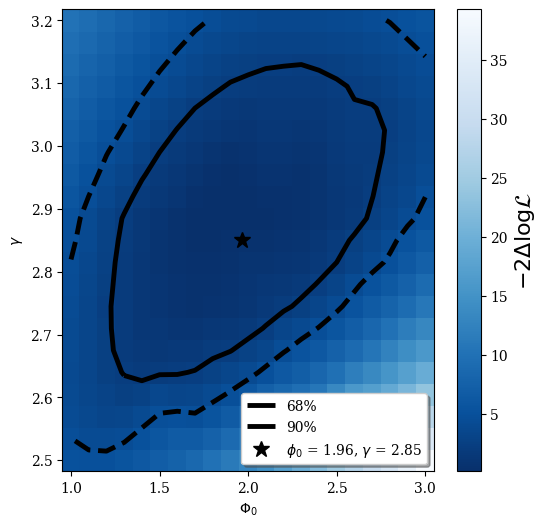

In [20]:
# --- single scan: contours + optional heatmap ---
name      = "param_scan"
best_fit  = scan_dict[name].get_freefit(drop_unsuccessful=True)

fig, ax = plot_2d_scan(
    x[name], y[name], dllh[name],
    best_fits  = best_fit,
    heatmap    = True,
    x_param    = x_param,
    y_param    = y_param,
)

fig.savefig(f"{plotting_path}/contour_heatmap_{name}.pdf")

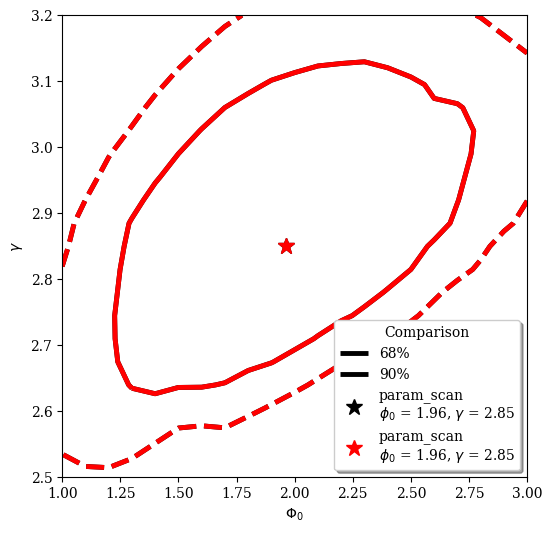

In [21]:
# --- comparison: overlay contours from two scans ---
name1 = "param_scan"
name2 = "param_scan"  # replace with a second scan name

best_fit1 = scan_dict[name1].get_freefit(drop_unsuccessful=True)
best_fit2 = scan_dict[name2].get_freefit(drop_unsuccessful=True)

fig, ax = plot_2d_scan(
    xs         = [x[name1],    x[name2]],
    ys         = [y[name1],    y[name2]],
    dllhs      = [dllh[name1], dllh[name2]],
    best_fits  = [best_fit1,   best_fit2],
    labels     = [name1,       name2],
    colors     = ["black",     "red"],
    levels     = [2.27, 4.60],
    levlabels  = ["68%", "90%"],
    x_param    = x_param,
    y_param    = y_param,
    heatmap    = False,
    legend_title = "Comparison",
)

# fig.savefig(f"{plotting_path}/compare_contour.pdf")